In [1]:
from autoenkoop import *
import torch
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import os
import pydmd
from tqdm import tqdm
from matplotlib.colors import Normalize

DEVICE = "cuda"

In [17]:
datatest = np.load(os.path.join("..", "data", "extracted_008n0.npz"))

In [19]:
datatest = datatest['timeseries']

In [15]:
data_path = os.path.join("..", "data", "T1492_x1151_y1_z127_c2.npz")
center_dataset = True
train_test_split = 0.7
train_data, test_data, temp_mean = load_and_prepare_data(data_path, center_dataset, train_test_split)

full_data = np.concatenate((train_data, test_data), axis=0)

original_data = full_data + temp_mean
temp_mean_error = np.mean((full_data - temp_mean)**2, axis=(1,2,3))
(vx_min, vx_max), (vz_min, vz_max) = get_min_max(original_data)
vx_absmax = max(abs(vx_min), abs(vx_max))
vz_absmax = max(abs(vz_min), abs(vz_max))
norm_x = Normalize(vmin=-vx_absmax, vmax=+vx_absmax)
norm_z = Normalize(vmin=-vz_absmax, vmax=+vz_absmax)

In [23]:
vx, vz = datatest[200,:, :, 0], datatest[200,:, :, 1]

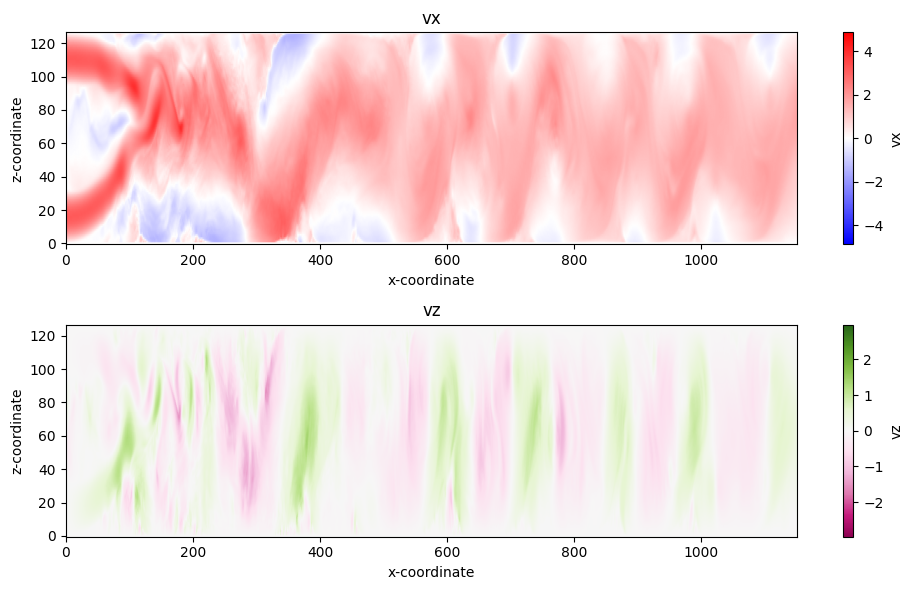

In [ ]:
# 1219

In [22]:
T, W, H, C = train_data.shape
print(train_data.shape)

(1045, 1151, 127, 2)


In [12]:
dataset = SimpleDataset(train_data)

In [92]:
class ResConv2D(nn.Module):
    def __init__(self, c):
        super().__init__()

        self.conv1 = torch.nn.Conv2d(c, c, 3, padding=1, bias=False)
        self.conv2 = torch.nn.Conv2d(c, c, 3, padding=1, bias=False)

        self.act = nn.GELU()

    def forward(self, x):

        y = self.conv1(x)
        y = self.act(y)
        y = self.conv2(y)

        return x + y

In [165]:
class PopulationNorm(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        if not self.training:
            print("not training")
        return x

In [166]:
flattened_dim = 128*17*3
intermediate_dimension = 1024
latent_dimension = 128

model = torch.nn.Sequential(*[
    torch.nn.Conv2d(2,32,kernel_size=(5,5),stride=(1,1),padding=(2,2),bias=False),
    PopulationNorm(),
    torch.nn.GELU(),
    torch.nn.AvgPool2d(kernel_size=(2,1), stride=(2,1)),
    torch.nn.Conv2d(32,64,kernel_size=(3,3),stride=(1,1),padding=(1,1),bias=False),
    PopulationNorm(),
    torch.nn.GELU(),
    torch.nn.AvgPool2d(kernel_size=(2,2), stride=(2,2)),
    torch.nn.Conv2d(64,96,kernel_size=(3,3),stride=(1,1),padding=(1,1),bias=False),
    PopulationNorm(),
    torch.nn.GELU(),
    torch.nn.AvgPool2d(kernel_size=(2,2), stride=(2,2)),
    torch.nn.Conv2d(96,128,kernel_size=(3,3),stride=(1,1),padding=(1,1),bias=False),
    PopulationNorm(),
    torch.nn.GELU(),
    torch.nn.AvgPool2d(kernel_size=(2,2), stride=(2,2)),
    torch.nn.Conv2d(128,128,kernel_size=(3,3),stride=(1,1),padding=(1,1),bias=False),
    PopulationNorm(),
    torch.nn.GELU(),
    torch.nn.AvgPool2d(kernel_size=(2,2), stride=(2,2)),
    torch.nn.Conv2d(128,128,kernel_size=(3,3),stride=(1,1),padding=(1,1),bias=False),
    PopulationNorm(),
    torch.nn.GELU(),
    torch.nn.AvgPool2d(kernel_size=(2,2), stride=(2,2)),
    nn.Flatten(),
    nn.Linear(flattened_dim, intermediate_dimension, bias=False),
    PopulationNorm(),
    torch.nn.GELU(),
    nn.Linear(intermediate_dimension, latent_dimension, bias=False)
])

In [169]:
model.eval()
y_list = []
with torch.no_grad():
    for i, x in enumerate(dataset):
        y = model(x.unsqueeze(0)).squeeze(0).numpy()
        if i == 0:
            print(y.shape)
        y_list.append(y)

not training
not training
not training
not training
not training
not training
not training
(128,)
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not training
not t

KeyboardInterrupt: 

6528

In [89]:
y_array = np.array(y_list)

In [90]:
print(np.mean(train_data, dtype=np.float64))

-4.186367770004007e-19


In [91]:
print(np.mean(y_array, dtype=np.float64))

-2.939071194773545e-12
